# Sweden grid — building & assembling the self-built 100m analysis grid

This notebook **imports**
`src/regions/sweden/sources/grid/{preprocess,side,assemble}.py` — the way
`barriers.ipynb`/`network.ipynb` do — runs each stage on the real fetched
data, and walks through the assembly process step by step, with the
intermediate geometry visualized at each stage. Full design brief:
[`docs/data/sweden/grid/README.md`](../../../docs/data/sweden/grid/README.md).

`grid` is a **second output spec** alongside `schools` (`schools/assemble.py`):
instead of matching noise barriers to *schools*, match them to a **100m x
100m grid cell**, assigning treated/untreated binary flags in distance
bands, a continuous distance-decay exposure index, barrier physical
covariates, and the "relevant side" vs. "wrong side" placebo distinction.
Same barrier layers (`noise_barriers`), same nearest-distance logic,
different unit of analysis — and, since SCB's real 100m population grid is
restricted MONA microdata (confirmed live, not assumed — see the README),
this source **builds its own 100m tiling** rather than reading one.

| file | grain | written by |
|---|---|---|
| `processed/grid_cells.parquet` | one row per 100m cell (within 1000m of any barrier) | `preprocess` |
| `assembled/grid_{road,rail}_rollup.parquet` | one row per cell, per barrier kind | `assemble` |
| `assembled/grid_barrier_rollup.parquet` | one row per cell, `{kind}_`-prefixed columns side by side | `assemble` |

Run with the `311` conda env (geopandas, pandas 3).

In [1]:
import sys
from pathlib import Path


def _find_repo_root(start: Path | None = None) -> Path:
    p = (start or Path.cwd()).resolve()
    for c in [p, *p.parents]:
        if (c / "src").is_dir() and (c / "data").is_dir():
            return c
    raise FileNotFoundError(f"repo root not found from {Path.cwd()}")


ROOT = _find_repo_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.experiments._setup import BLUE, GREEN, GREY, ORANGE, RED, np, pd, plt

import geopandas as gpd
from shapely.ops import unary_union

from src.regions.sweden.sources.grid import preprocess as PRE
from src.regions.sweden.sources.grid import assemble as ASM
from src.regions.sweden.sources.grid import side as SIDE
from src.regions.sweden.sources.grid import shared as SH
from src.regions.sweden.sources.noise_barriers.shared import BARRIER_KINDS, load_noise_barriers
from src.regions.sweden.sources.road_network.shared import load_road_network

import json
import time

pd.set_option("display.max_columns", 60)

ROOT

PosixPath('/Users/felixschulz/Library/CloudStorage/OneDrive-Personal/Dokumente/Job/UNI/Basel/Research/noise-pollution')

## 1. Why not tile all of Sweden — buffering barriers into a corridor

A nationwide 100m fishnet over Sweden would be ~45M cells, and almost all of
them are pointless: any cell further than the widest configured band
(`BAND_RADII_M = (100, 200, 300, 400, 500, 1000)`, so `BUFFER_M = 1000`)
from *every* barrier is guaranteed `ever_near_*m = False` under every band.
`preprocess.py::build_grid_cells` buffers every barrier geometry (road +
rail together) by `BUFFER_M`, takes the union, and only tiles that corridor.

In [2]:
barriers_by_kind = {kind: load_noise_barriers(kind, ROOT) for kind in BARRIER_KINDS}
for kind, gdf in barriers_by_kind.items():
    print(f"{kind:5s} barriers: {len(gdf):,}")

all_geoms = [
    geom for gdf in barriers_by_kind.values() for geom in gdf.to_crs(SH.METRIC_CRS).geometry
]
corridor = unary_union([geom.buffer(SH.BUFFER_M) for geom in all_geoms])
components = list(corridor.geoms) if corridor.geom_type == "MultiPolygon" else [corridor]
areas_km2 = sorted((c.area / 1e6 for c in components), reverse=True)

print(f"\nbuffered union ({SH.BUFFER_M:.0f}m): {len(components)} disjoint components")
print(f"total corridor area: {sum(areas_km2):,.0f} km^2  |  largest component: {areas_km2[0]:,.1f} km^2")

road  barriers: 2,172
rail  barriers: 1,829



buffered union (1000m): 694 disjoint components
total corridor area: 4,004 km^2  |  largest component: 55.3 km^2


Confirms the README's live 2026-09-22 finding, not just cited from it: the
buffered corridor is **694 disjoint components**, not one country-spanning
blob — barriers cluster near settlements and along specific motorway/rail
corridors, so most of Sweden's land area is never a candidate at all.

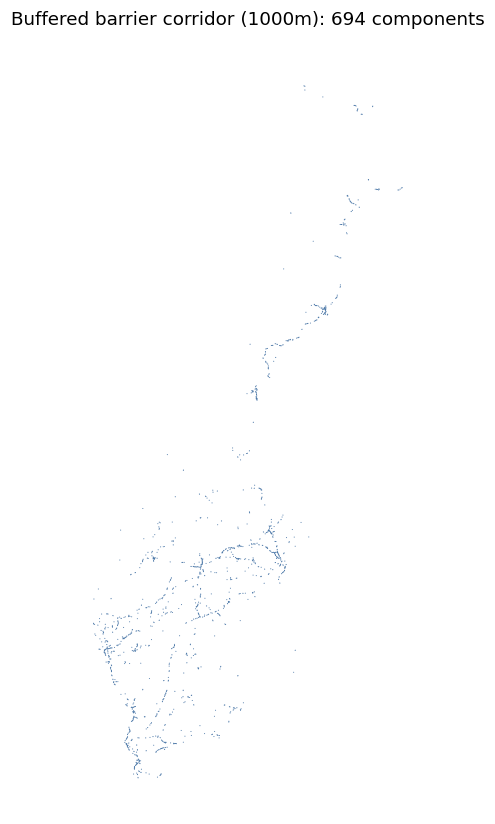

In [3]:
fig, ax = plt.subplots(figsize=(6, 9))
gpd.GeoSeries(components, crs=SH.METRIC_CRS).plot(ax=ax, color=BLUE, edgecolor="none")
ax.set_title(f"Buffered barrier corridor ({SH.BUFFER_M:.0f}m): {len(components)} components")
ax.set_axis_off()
plt.show()

## 2. Tiling one component — candidate meshgrid vs. cells actually kept

Tiling is done **per connected component**, each within its own small
bounding box, rather than one pass over the corridor's overall bounding box
(~623km x 1392km for road alone — that would mean materializing tens of
millions of candidate cells before filtering). `_tile_component` still
overshoots a little: it builds a rectangular meshgrid over each component's
own bounding box, then keeps only the cells whose centroid actually falls
*inside* that component's (usually irregular, elongated) polygon.

Below: the largest component by area — every candidate meshgrid point in
its bounding box (grey) vs. the subset whose centroid lands inside the
buffered corridor (blue, the cells that actually get built). §1 measures it
live at ~55 km² against the current barrier data — smaller than the
~185 km² `preprocess.py`'s own docstring quotes, although §1's component
count and total area, and §3's cell count, all match the README exactly;
most likely a stale docstring number.

bounding-box candidates: 11,988  |  kept (inside corridor): 5,535  |  overshoot ratio: 2.17x


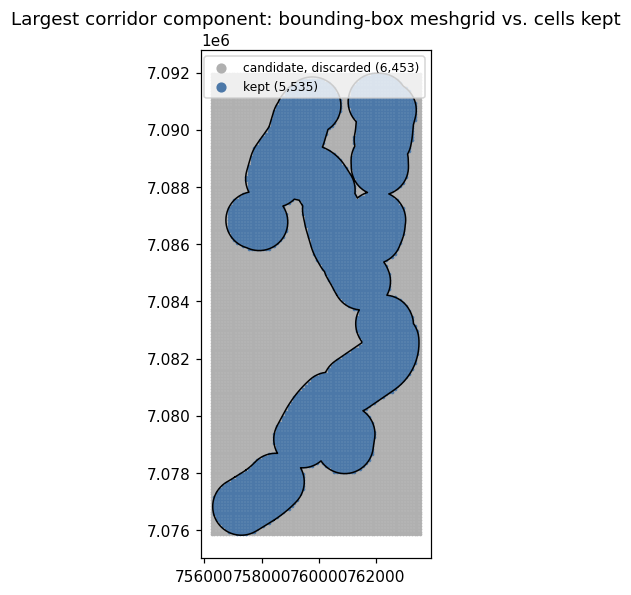

In [4]:
import math

largest = max(components, key=lambda c: c.area)
resolution_m = SH.RESOLUTION_M
minx, miny, maxx, maxy = largest.bounds
x0 = math.floor(minx / resolution_m) * resolution_m
y0 = math.floor(miny / resolution_m) * resolution_m
x1 = math.ceil(maxx / resolution_m) * resolution_m
y1 = math.ceil(maxy / resolution_m) * resolution_m

eastings = np.arange(x0, x1, resolution_m, dtype=np.int64)
northings = np.arange(y0, y1, resolution_m, dtype=np.int64)
xx, yy = np.meshgrid(eastings, northings)
sw_easting, sw_northing = xx.ravel(), yy.ravel()
centroids = gpd.points_from_xy(sw_easting + resolution_m / 2, sw_northing + resolution_m / 2)
within = gpd.GeoSeries(centroids, crs=SH.METRIC_CRS).within(largest).to_numpy()

print(f"bounding-box candidates: {within.size:,}  |  kept (inside corridor): {within.sum():,}"
      f"  |  overshoot ratio: {within.size / within.sum():.2f}x")

fig, ax = plt.subplots(figsize=(8, 6))
gpd.GeoSeries([largest], crs=SH.METRIC_CRS).boundary.plot(ax=ax, color="black", linewidth=1)
ax.scatter(sw_easting[~within] + resolution_m / 2, sw_northing[~within] + resolution_m / 2,
           s=2, color=GREY, label=f"candidate, discarded ({(~within).sum():,})")
ax.scatter(sw_easting[within] + resolution_m / 2, sw_northing[within] + resolution_m / 2,
           s=2, color=BLUE, label=f"kept ({within.sum():,})")
ax.set_title("Largest corridor component: bounding-box meshgrid vs. cells kept")
ax.legend(markerscale=4, loc="upper right", fontsize=8)
ax.set_aspect("equal")
plt.show()

This single component's own overshoot ratio (above) needn't match the
README's "~1.6x" — that figure is the *aggregate* over all 694 components,
and an elongated component's bounding box wastes more of itself than a
compact one. Either way, per-component tiling beats materializing the whole
corridor's ~623km x 1392km bounding box by roughly two orders of magnitude.

## 3. `preprocess` — build & persist the full 400k-cell grid

Runs the same logic as above (§1-2) over all 694 components and writes
`processed/grid_cells.parquet`. `cell_id` is keyed on the cell's SW corner
in SWEREF99 TM, snapped to multiples of `RESOLUTION_M`
(`SE{res}mN{northing}E{easting}`) — the same convention SCB's/INSPIRE's real
grids use, so these cells line up with the real one if MONA access is ever
obtained.

In [5]:
report = PRE.run_grid_preprocess()
print(json.dumps({k: v for k, v in report.items() if k != "saved"}, indent=1))
print("saved", Path(report["saved"]).relative_to(ROOT))

{
 "n_cells": 400369,
 "resolution_m": 100,
 "buffer_m": 1000,
 "kinds": [
  "road",
  "rail"
 ]
}
saved data/sweden/grid/processed/grid_cells.parquet


In [6]:
cells_gdf = gpd.read_parquet(SH.processed_grid_cells_path(ROOT))
cells_gdf.head(3)

,cell_id,easting,northing,geometry
0,SE100mN6374200E318200,318200,6374200,POINT (318250 6374250)
1,SE100mN6374200E318300,318300,6374200,POINT (318350 6374250)
2,SE100mN6374200E318400,318400,6374200,POINT (318450 6374250)


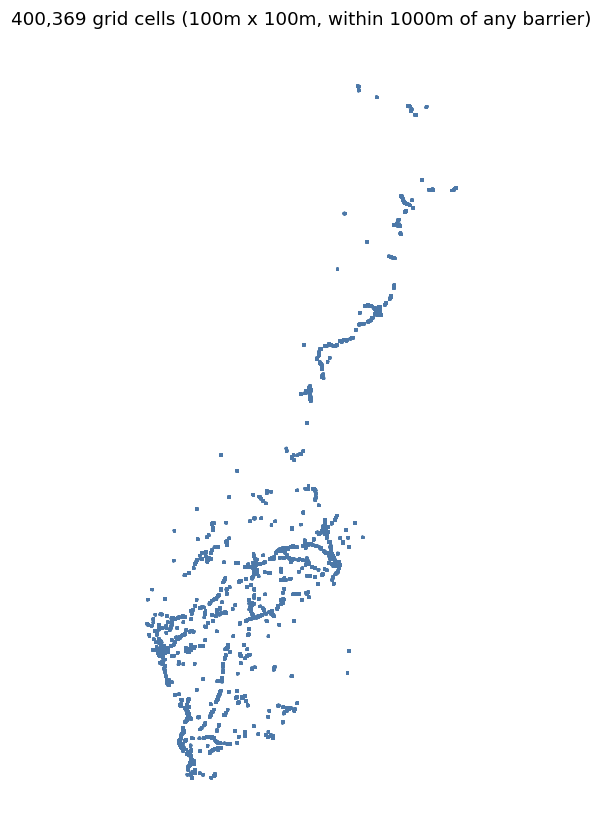

In [7]:
fig, ax = plt.subplots(figsize=(6, 9))
ax.scatter(cells_gdf.geometry.x, cells_gdf.geometry.y, s=0.15, color=BLUE, alpha=0.5)
ax.set_title(f"{len(cells_gdf):,} grid cells (100m x 100m, within {SH.BUFFER_M:.0f}m of any barrier)")
ax.set_aspect("equal")
ax.set_axis_off()
plt.show()

## 4. `assemble` step 1 — nearest-barrier point matching (`match_grid_point`)

Grid cell counts (hundreds of thousands) are too large for
`schools/assemble.py::match_barriers_point`'s dense distance-matrix approach
(cheap only at a few thousand schools) — `match_grid_point` uses the same
spatial-index nearest-neighbour join (`gpd.sjoin_nearest` under the hood)
the road/rail network-matching algorithms already use: one nearest-distance
value per cell per kind, and `ever_near_{radius}m` is just a threshold on
it, one per configured band.

In [8]:
point_rollups = {}
for kind in BARRIER_KINDS:
    barriers_gdf = load_noise_barriers(kind, ROOT)
    point_rollups[kind] = ASM.match_grid_point(cells_gdf, barriers_gdf)
    r = point_rollups[kind]
    print(f"{kind:5s}: nearest_dist_m median {r['nearest_dist_m'].median():.0f}m"
          f"  |  ever_treated (<=1000m) {r['ever_treated'].sum():,} / {len(r):,}")

road : nearest_dist_m median 831m  |  ever_treated (<=1000m) 271,116 / 400,369


rail : nearest_dist_m median 4224m  |  ever_treated (<=1000m) 145,286 / 400,369


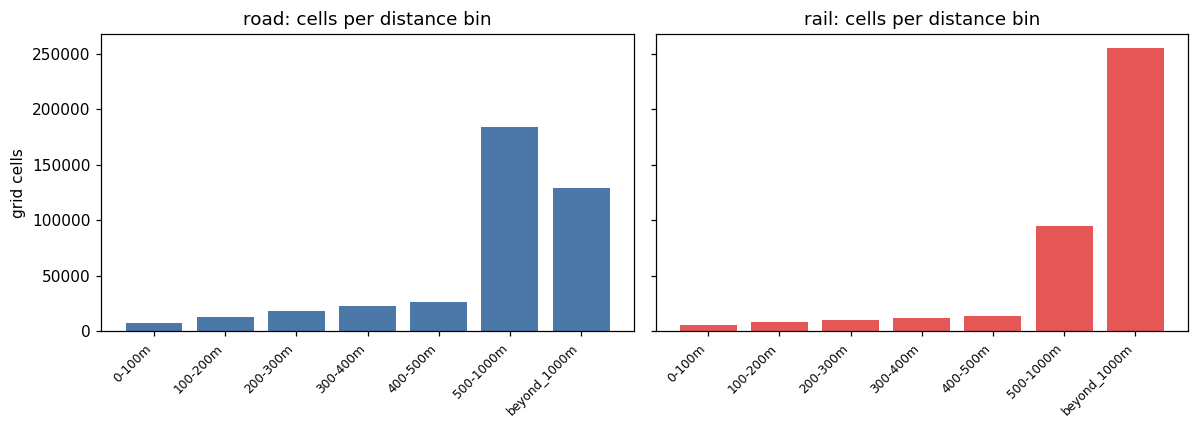

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, kind, color in zip(axes, BARRIER_KINDS, (BLUE, RED)):
    r = point_rollups[kind]
    order = [f"{lo}-{hi}m" for lo, hi in zip([0, *SH.BAND_RADII_M[:-1]], SH.BAND_RADII_M)] + [f"beyond_{SH.BAND_RADII_M[-1]}m"]
    counts = r["dist_bin"].value_counts().reindex(order)
    ax.bar(range(len(counts)), counts.to_numpy(), color=color)
    ax.set_xticks(range(len(counts)))
    ax.set_xticklabels(counts.index, rotation=45, ha="right", fontsize=8)
    ax.set_title(f"{kind}: cells per distance bin")
axes[0].set_ylabel("grid cells")
plt.tight_layout()
plt.show()

`beyond_{max}m` exists because a per-*kind* `nearest_dist_m` can exceed
`max(BAND_RADII_M)` even though the grid's own tiling buffer doesn't: the
buffer is unioned across BOTH kinds, so a cell can be well inside the
buffer via its nearest RAIL barrier while its nearest ROAD barrier is tens
of km away — visible above as road's large `beyond_1000m` bar, purely
rail-corridor territory.

## 5. The distance-decay exposure index

`compute_relative_loudness_reduction_pct` reproduces Moretti & Wheeler
(2025)'s Appendix Table A3 physics: inverse-square-law decibel decay (-6 dB
per doubling of distance) from a 76 dB/25m reference, a barrier's assumed
7 dB attenuation subtracted, converted to a 0-100 perceived-loudness scale
(every 10 dB drop halves perceived loudness). Clamped at 25m (the paper's
own nearest tabulated distance) — an unclamped version blew up past 250 for
cells a few metres from their nearest barrier, confirmed live while
building it.

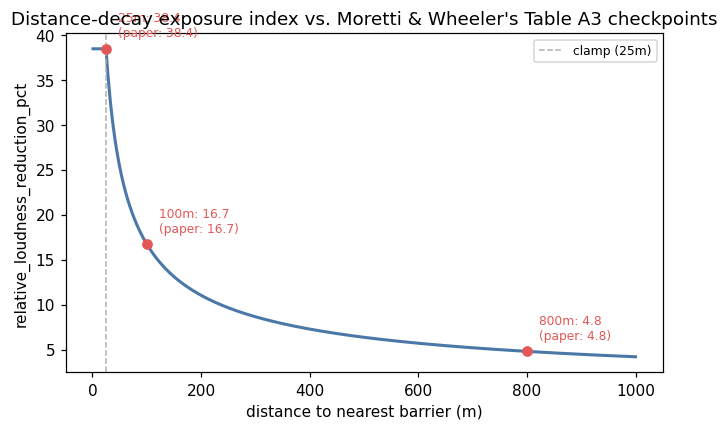

In [10]:
dist_grid = np.linspace(1, 1000, 500)
reduction = ASM.compute_relative_loudness_reduction_pct(dist_grid)

checkpoints = {25: 38.4, 100: 16.7, 800: 4.8}  # paper's own Appendix Table A3 worked values
computed_checkpoints = {d: float(ASM.compute_relative_loudness_reduction_pct(np.array([d]))[0]) for d in checkpoints}

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(dist_grid, reduction, color=BLUE, linewidth=2)
for d, paper_val in checkpoints.items():
    ax.scatter([d], [computed_checkpoints[d]], color=RED, zorder=5)
    ax.annotate(f"{d}m: {computed_checkpoints[d]:.1f}\n(paper: {paper_val})", (d, computed_checkpoints[d]),
                textcoords="offset points", xytext=(8, 8), fontsize=8, color=RED)
ax.axvline(25, color=GREY, linestyle="--", linewidth=1, label="clamp (25m)")
ax.set_xlabel("distance to nearest barrier (m)")
ax.set_ylabel("relative_loudness_reduction_pct")
ax.set_title("Distance-decay exposure index vs. Moretti & Wheeler's Table A3 checkpoints")
ax.legend(fontsize=8)
plt.show()

## 6. Which side of the road — the protected area (`_barrier_reference.py`)

A barrier protects the area on its far side from the traffic, along the
stretch it covers. `grid/side.py` judges each cell against its nearest
barrier via `src/regions/sweden/sources/_barrier_reference.py` — the **same
implementation `schools/assemble.py` uses for schools**. Full review and
validation: [`docs/data/sweden/barrier_matching.md`](../../../docs/data/sweden/barrier_matching.md).

- **Which stretch.** A barrier's `element_id` is the NVDB road/track link
  it is registered on, and its measures give its position along it. So the
  network rows it covers come from an exact key join (100% of road and
  99.7% of rail barriers), not a nearest-distance guess.
- **Which side.** This is the hard part. Trafikverket barrier geometry sits
  *on* the centreline, for road (99.8%) and for rail (99.7% within 1mm),
  and its `side` attribute carries no signal. So the side comes from the
  first method that applies:

| `side_method` | how the side is decided | validation |
|---|---|---|
| `both_sides` (road) | a second barrier covers the same stretch of the same road link, labelled for the other side: walls on both sides | all 58 such pairs are left + right; OSM shows walls on both sides for 7/12 (vs 3/33 for single barriers) |
| `osm_offset` | an OpenStreetMap wall runs alongside the barrier, beside its own road (rail: at the barrier's recorded distance from the track, where recorded) | direct observation |
| `geometric_offset` | the barrier's own geometry sits ≥1m off its road | rare (~0.3%) |
| `track_offset` (rail) | the barrier's distance from its track is recorded and another track runs alongside; the wall stands on the side away from it | 27/28 agreement with OSM walls at the recorded distance |
| `parallel_road` (road) | another road runs alongside for ±200m (divided road, ramp beside a mainline); the wall stands on the side away from it | 93% / 100% agreement with tagged / untyped OSM walls |
| `unknown` | none of the above | never counted as the protected side; flagged `same_side_unknown` |

Every sign is taken against one line per barrier, its **through-line**:
the road followed across junctions, ~800m each way. Cell and barrier are
therefore always compared along the same line.

**The protected area.** Side alone isn't enough. The corridor reaches
~800m along the road, but the median barrier is only ~70m long, and a wall
only shields what lies *beside* it. `protected` means same side, within
50m (half a cell) of the barrier's own stretch along the road, and within
600m of the road. `barrier-protection build` draws that area for every
barrier in Sweden as a polygon (§8). A cell is protected if **any**
barrier's area contains it, not only its nearest barrier's.

The cases below run live on real barriers. Each one clips the national
road network to a 5km window around its example, so it runs in seconds
instead of loading 2M rows. Results are identical to the full run, since
nothing the method looks at reaches beyond ~1.1km from the barrier.

In [11]:
from src.core.barrier_geometry.protection import protection_zones
from src.regions.sweden.sources._barrier_reference import build_barrier_references
from src.regions.sweden.sources._layout import METRIC_CRS
from src.regions.sweden.sources.osm_walls.shared import load_osm_walls

roads_all = load_road_network(ROOT).to_crs(METRIC_CRS)
osm_all = load_osm_walls(ROOT)
road_barriers_all = load_noise_barriers("road", ROOT).to_crs(METRIC_CRS)
CATEGORY_COLORS = {
    "not in route corridor": GREY,
    "wrong side (placebo)": ORANGE,
    "unknown side, past the stretch": "#C2A5CF",
    "same side, past the stretch": "#9ECAE1",
    "unknown side, beside the stretch": "#7B3294",
    "protected (same side, beside the stretch)": BLUE,
}


def run_case(center, title, half=1200, margin=3000):
    x, y = center.x, center.y
    net = roads_all.cx[x - half - margin:x + half + margin, y - half - margin:y + half + margin]
    barriers = road_barriers_all.cx[x - half - 500:x + half + 500, y - half - 500:y + half + 500].reset_index(drop=True)
    cells = cells_gdf.cx[x - half:x + half, y - half:y + half].reset_index(drop=True)

    refs = build_barrier_references(barriers, net, osm_walls=osm_all, kind="road")
    zones = protection_zones(refs)
    nearest_side = SIDE.match_grid_side(cells, barriers, refs)
    protection = SIDE.match_grid_protection(cells, barriers, refs)
    out = cells.merge(nearest_side, on="cell_id").merge(protection, on="cell_id")
    nearest = ASM.match_grid_point(cells, barriers)["nearest_barrier_row"].to_numpy()
    out["category"] = np.select(
        [~out["same_route"], out["protected"], out["protected_unknown"], out["same_side"], out["same_side_unknown"]],
        [
            "not in route corridor",
            "protected (same side, beside the stretch)",
            "unknown side, beside the stretch",
            "same side, past the stretch",
            "unknown side, past the stretch",
        ],
        default="wrong side (placebo)",
    )

    fig, ax = plt.subplots(figsize=(8, 8))
    net.cx[x - half:x + half, y - half:y + half].plot(ax=ax, color=GREY, linewidth=0.5, alpha=0.5)
    for status, color in (("protected", BLUE), ("side_unknown", "#7B3294")):
        sub = zones[zones["zone_status"] == status]
        if len(sub):
            sub.plot(ax=ax, color=color, alpha=0.12, zorder=1)
    for cat, color in CATEGORY_COLORS.items():
        sub = out[out["category"] == cat]
        if len(sub):
            ax.scatter(sub.geometry.x, sub.geometry.y, s=14, color=color, label=f"{cat} ({len(sub)})", zorder=3)
    for br, line in refs.lines.items():
        gpd.GeoSeries([line], crs=METRIC_CRS).plot(ax=ax, color=RED, linewidth=1.2, linestyle="--", zorder=2)
    walls = osm_all.cx[x - half:x + half, y - half:y + half]
    if len(walls):
        walls.plot(ax=ax, color=GREEN, linewidth=2.5, zorder=4, label="OSM wall")
    barriers.plot(ax=ax, color="black", linewidth=3, zorder=5, label="Trafikverket barrier")
    ax.plot([], [], color=RED, linestyle="--", label="barrier through-line (side reference)")
    ax.fill([], [], color=BLUE, alpha=0.12, label="protection zone (side known / unknown: purple)")
    ax.set_xlim(x - half, x + half); ax.set_ylim(y - half, y + half); ax.set_aspect("equal")
    ax.set_title(title); ax.legend(fontsize=7, loc="lower left")
    plt.show()

    table = refs.table[["side_method", "barrier_sign", "osm_id"]].assign(element_id=barriers["element_id"])
    counts = out[out["same_route"]].assign(barrier_row=nearest[out["same_route"]]).groupby("barrier_row").agg(
        cells_same_route=("same_route", "size"),
        cells_same_side=("same_side", "sum"),
        cells_side_unknown=("same_side_unknown", "sum"),
    )
    protected_by = out.loc[out["protected"], "protected_barrier_row"].astype(int).value_counts().rename("cells_protected")
    table = table.join(counts).join(protected_by).fillna({"cells_same_route": 0, "cells_protected": 0})
    return table.astype({"cells_same_route": int, "cells_protected": int})

#### Case 1 — the Nacka off-ramp beside a school

Barrier `12732:220514` on Värmdöleden (route 222) at the Sickla/Järla
interchange, 59.3117°N 18.1513°E. Checked independently: it stands on the
**outside of the off-ramp, next to a school**. Before the rewrite, the
school-matching code forced every nearby cell to "same side" for this
barrier, because no divided-road sibling was found.

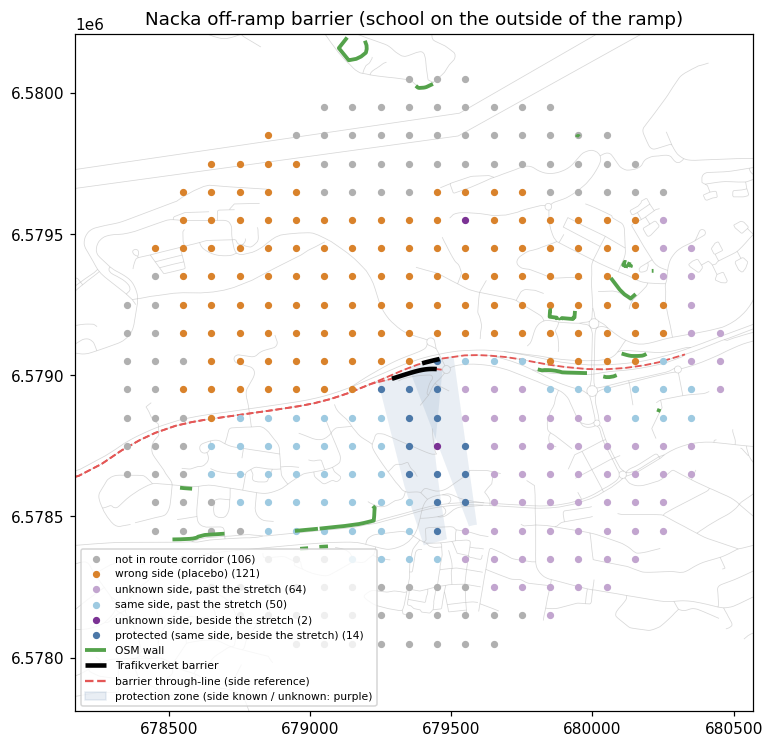

,side_method,barrier_sign,osm_id,element_id,cells_same_route,cells_same_side,cells_side_unknown,cells_protected
0,parallel_road,-1.0,<NA>,1000:82472,86,14,11,4
1,parallel_road,-1.0,<NA>,12732:220514,165,47,57,10


In [12]:
nacka = road_barriers_all.loc[1597].geometry.centroid
run_case(nacka, "Nacka off-ramp barrier (school on the outside of the ramp)")

#### Case 2 — a barrier whose side comes straight from an OSM wall

The example is picked from the full run (§7 writes the rollup this reads):
the barrier link with the most `osm_offset` cells. The green OSM wall,
drawn beside the road, is what decides the side here, not an inference.

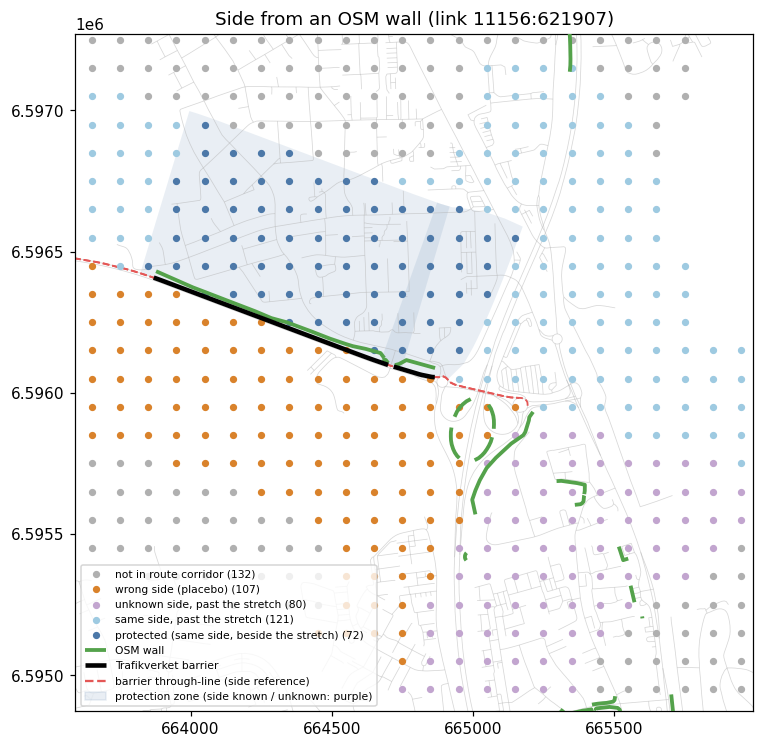

,side_method,barrier_sign,osm_id,element_id,cells_same_route,cells_same_side,cells_side_unknown,cells_protected
0,osm_offset,-1.0,819771696,11156:621907,236,115,80,14
1,osm_offset,-1.0,819771694,11156:621907,144,78,0,58


In [13]:
prev = pd.read_parquet(SH.assembled_dir(ROOT) / "grid_road_rollup.parquet")
osm_link = prev.loc[prev["side_method"] == "osm_offset", "nearest_element_id"].value_counts().index[0]
osm_center = road_barriers_all.loc[road_barriers_all["element_id"] == osm_link].geometry.iloc[0].centroid
run_case(osm_center, f"Side from an OSM wall (link {osm_link})")

#### Case 3 — a barrier whose side can't be determined

The link with the most `same_side_unknown` cells: an undivided road with
no OSM wall and no road running alongside. Purple cells are in the
barrier's route corridor, but which side the wall protects is genuinely
unknown. They are **not** counted as protected, and they are flagged, so
an analysis can exclude them rather than treat them as untreated. These
are the barriers the planned manual-audit app is for (see
`barrier_matching.md` §5).

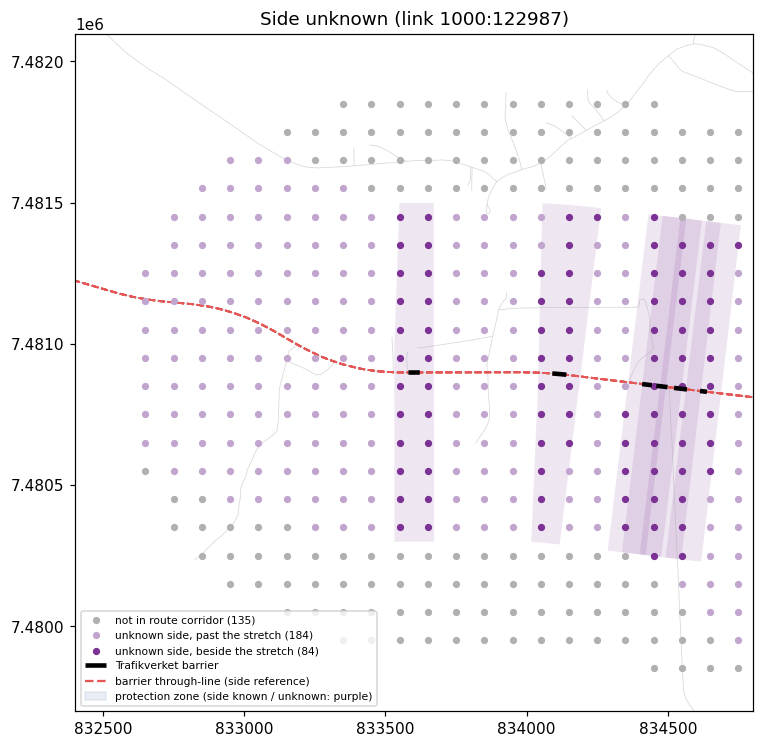

,side_method,barrier_sign,osm_id,element_id,cells_same_route,cells_same_side,cells_side_unknown,cells_protected
0,unknown,0.0,<NA>,1000:122987,153,0,153,0
1,unknown,0.0,<NA>,1000:122987,44,0,44,0
2,unknown,0.0,<NA>,1000:122987,32,0,32,0
3,unknown,0.0,<NA>,1000:122987,7,0,7,0
4,unknown,0.0,<NA>,1000:122987,23,0,23,0
5,unknown,0.0,<NA>,1000:122987,9,0,9,0


In [14]:
unknown_link = prev.loc[prev["same_side_unknown"], "nearest_element_id"].value_counts().index[0]
unknown_center = road_barriers_all.loc[road_barriers_all["element_id"] == unknown_link].geometry.iloc[0].centroid
run_case(unknown_center, f"Side unknown (link {unknown_link})")

#### Case 4 — walls on both sides of the road

Two barriers registered on the same stretch of the same road link, one
labelled left and one right. Both sides of the road are protected beside
the stretch. Picked as the longest such barrier.

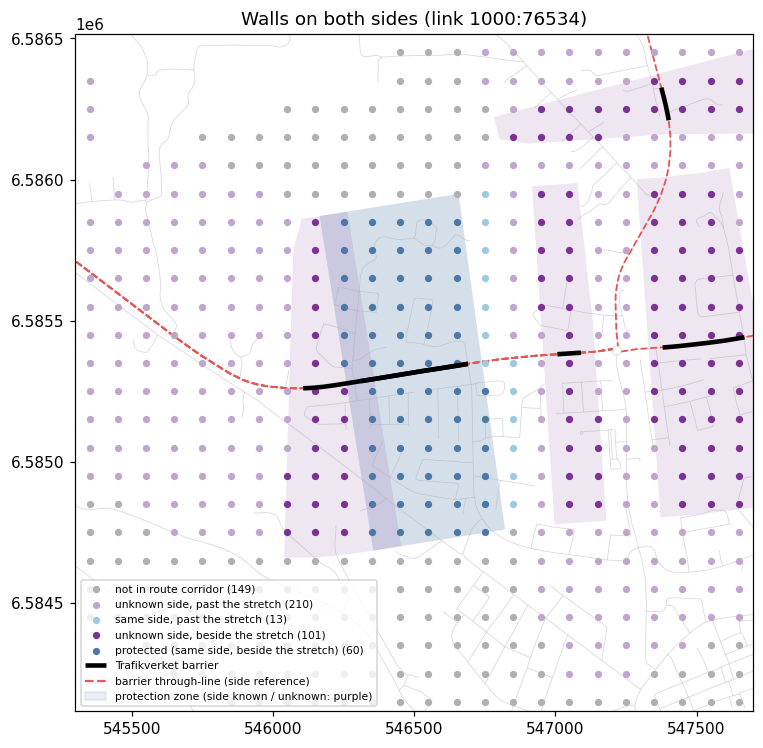

,side_method,barrier_sign,osm_id,element_id,cells_same_route,cells_same_side,cells_side_unknown,cells_protected
0,unknown,0.0,<NA>,1000:76181,65,0,65,0
1,unknown,0.0,<NA>,1000:76486,61,0,61,0
2,both_sides,0.0,<NA>,1000:76534,63,63,0,34
3,unknown,0.0,<NA>,1000:76534,64,0,64,0
4,both_sides,0.0,<NA>,1000:76534,3,3,0,26
5,unknown,0.0,<NA>,1000:76534,128,0,128,0


In [15]:
from src.regions.sweden.sources._barrier_reference import both_sides_rows

both_rows = sorted(both_sides_rows(road_barriers_all.reset_index(drop=True)))
both = road_barriers_all.reset_index(drop=True).loc[both_rows]
both_center = both.geometry.length.idxmax()
run_case(both.geometry.loc[both_center].centroid, f"Walls on both sides (link {both.loc[both_center, 'element_id']})")

## 7. Full `assemble` run — real numbers, road vs. rail

`run_grid_assemble` runs the point match (§4) and the side match (§6) for
both barrier kinds, over all 400k cells, and writes the per-kind and
combined rollups. `add_side_treatment_definitions` gates
`ever_treated_same_route` / `ever_treated_same_side` /
`ever_treated_protected` on the point-distance `ever_treated`; unknown-side
cells are never in `ever_treated_same_side` or `ever_treated_protected`.

In [16]:
t0 = time.time()
report = ASM.run_grid_assemble()
print(f"elapsed {time.time() - t0:.0f}s")
print(json.dumps({k: v for k, v in report.items() if k != "combined_rollup_path"}, indent=1))

elapsed 40s
{
 "n_cells": 400369,
 "band_radii_m": [
  100,
  200,
  300,
  400,
  500,
  1000
 ],
 "kinds": {
  "road": {
   "n_barriers": 2172,
   "n_ever_treated": 271116,
   "n_timing_unknown": 162328,
   "n_ever_treated_same_route": 204012,
   "n_ever_treated_same_side": 61143,
   "n_ever_treated_same_side_unknown": 91370,
   "n_ever_treated_protected": 17152,
   "n_ever_treated_protected_unknown": 10957,
   "n_ever_treated_protected_by_several_barriers": 3798,
   "n_ever_treated_protected_not_by_nearest": 2875,
   "ever_treated_same_route_by_side_method": {
    "parallel_road": 103245,
    "unknown": 85330,
    "osm_offset": 13644,
    "both_sides": 1490,
    "geometric_offset": 303
   },
   "dist_bin_counts": {
    "0-100m": 7685,
    "100-200m": 13032,
    "200-300m": 17844,
    "300-400m": 22304,
    "400-500m": 26253,
    "500-1000m": 183998,
    "beyond_1000m": 129253
   },
   "n_ever_near_100m": 7685,
   "n_ever_near_200m": 20717,
   "n_ever_near_300m": 38561,
   "n_ever_ne

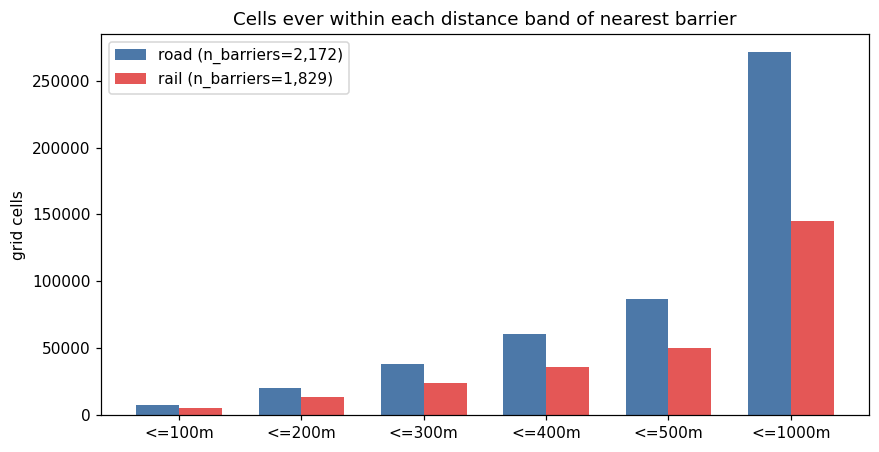

In [17]:
summary = report["kinds"]
bands = [f"ever_near_{r}m" for r in SH.BAND_RADII_M]
fig, ax = plt.subplots(figsize=(9, 4.5))
width = 0.35
x = np.arange(len(bands))
for i, (kind, color) in enumerate(zip(BARRIER_KINDS, (BLUE, RED))):
    counts = [summary[kind][f"n_{b}"] for b in bands]
    ax.bar(x + (i - 0.5) * width, counts, width=width, label=f"{kind} (n_barriers={summary[kind]['n_barriers']:,})", color=color)
ax.set_xticks(x)
ax.set_xticklabels([b.replace("ever_near_", "<=") for b in bands])
ax.set_ylabel("grid cells")
ax.set_title("Cells ever within each distance band of nearest barrier")
ax.legend()
plt.show()

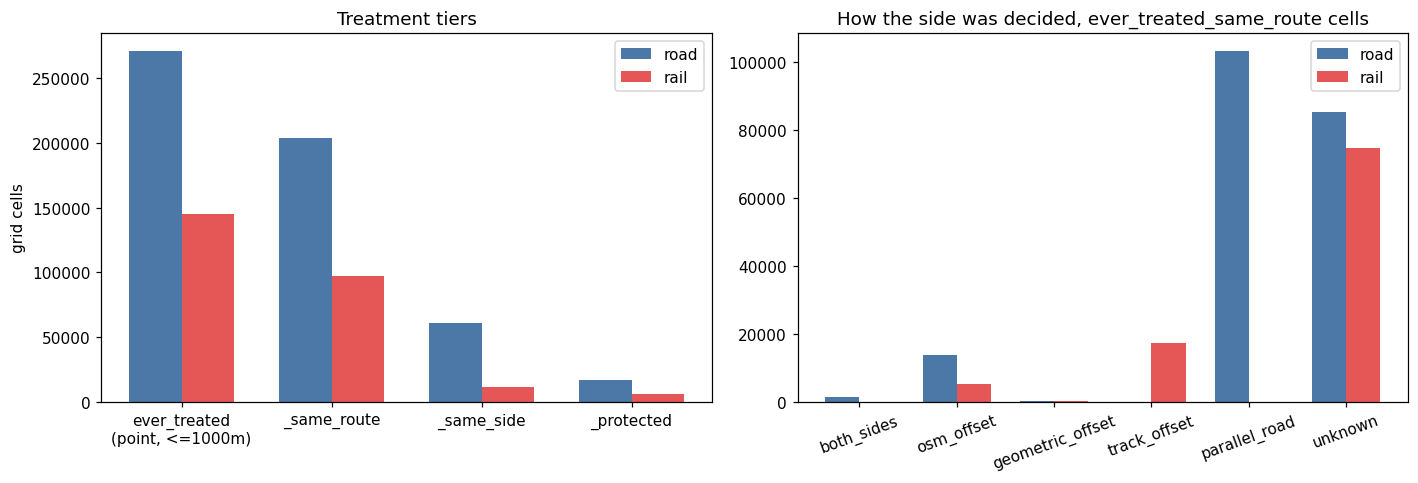

In [18]:
methods = ["both_sides", "osm_offset", "geometric_offset", "track_offset", "parallel_road", "unknown"]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
tiers = ["n_ever_near_1000m", "n_ever_treated_same_route", "n_ever_treated_same_side", "n_ever_treated_protected"]
x = np.arange(len(tiers))
for i, (kind, color) in enumerate(zip(BARRIER_KINDS, (BLUE, RED))):
    s = summary[kind]
    axes[0].bar(x + (i - 0.5) * width, [s[t] for t in tiers], width=width, label=kind, color=color)
axes[0].set_xticks(x)
axes[0].set_xticklabels(["ever_treated\n(point, <=1000m)", "_same_route", "_same_side", "_protected"])
axes[0].set_ylabel("grid cells")
axes[0].set_title("Treatment tiers")
axes[0].legend()

x = np.arange(len(methods))
for i, (kind, color) in enumerate(zip(BARRIER_KINDS, (BLUE, RED))):
    by_method = summary[kind]["ever_treated_same_route_by_side_method"]
    axes[1].bar(x + (i - 0.5) * width, [by_method.get(m, 0) for m in methods], width=width, label=kind, color=color)
axes[1].set_xticks(x)
axes[1].set_xticklabels(methods, rotation=20)
axes[1].set_title("How the side was decided, ever_treated_same_route cells")
axes[1].legend()
plt.tight_layout()
plt.show()

The right panel is the honest state of the side model. Road cells get a
real side mostly from `parallel_road`, with a smaller OSM share. Rail
barrier geometry is snapped onto the track, so rail cells have a known
side only from an OSM wall or from `track_offset` (recorded distance plus
a second track). The left panel shows how much narrower `protected` is
than `same_side`: most same-side cells lie along the road past the
barrier's own stretch.

## 8. The national protection layer (`barrier-protection build`)

Everything above is computed once per barrier kind by
`sweden data barrier-protection build` (about 2.5 minutes for all of
Sweden) and saved. Schools and the grid load the saved references rather
than recomputing them, and **any other analysis can use the protection
layer directly**:

```python
from src.regions.sweden.sources.barrier_protection.shared import load_protection_zones
zones = load_protection_zones()        # both kinds; EPSG:3006
units.sjoin(zones, predicate="within")  # any points: addresses, sales, DeSO centroids, ...
```

There is one polygon per barrier: every point on the barrier's side,
within 600m of its road, whose nearest point on the road lies within the
barrier's stretch ±50m. A point in front of a wall but nearer another,
unshielded part of the same road (inside a bend) gets that part's noise, so
it isn't in the zone. `zone_status` is `protected`, or `side_unknown` when
the barrier's side isn't known: then the area is drawn on both sides and
must not be counted as protected. Each row carries the
barrier's `kind`, `side_method`, `built_year` and key columns. For exact
per-point distances (`lateral_m`, `along_offset_m`), use
`load_barrier_references` + `classify_points`, as `grid/side.py` does.

"km², dissolved",protected,side_unknown
kind,,
rail,59.2,223.1
road,172.1,119.2


kind,rail,road
side_method,,
both_sides,0,112
geometric_offset,6,1
osm_offset,99,194
parallel_road,0,1230
track_offset,629,0
unknown,1095,635


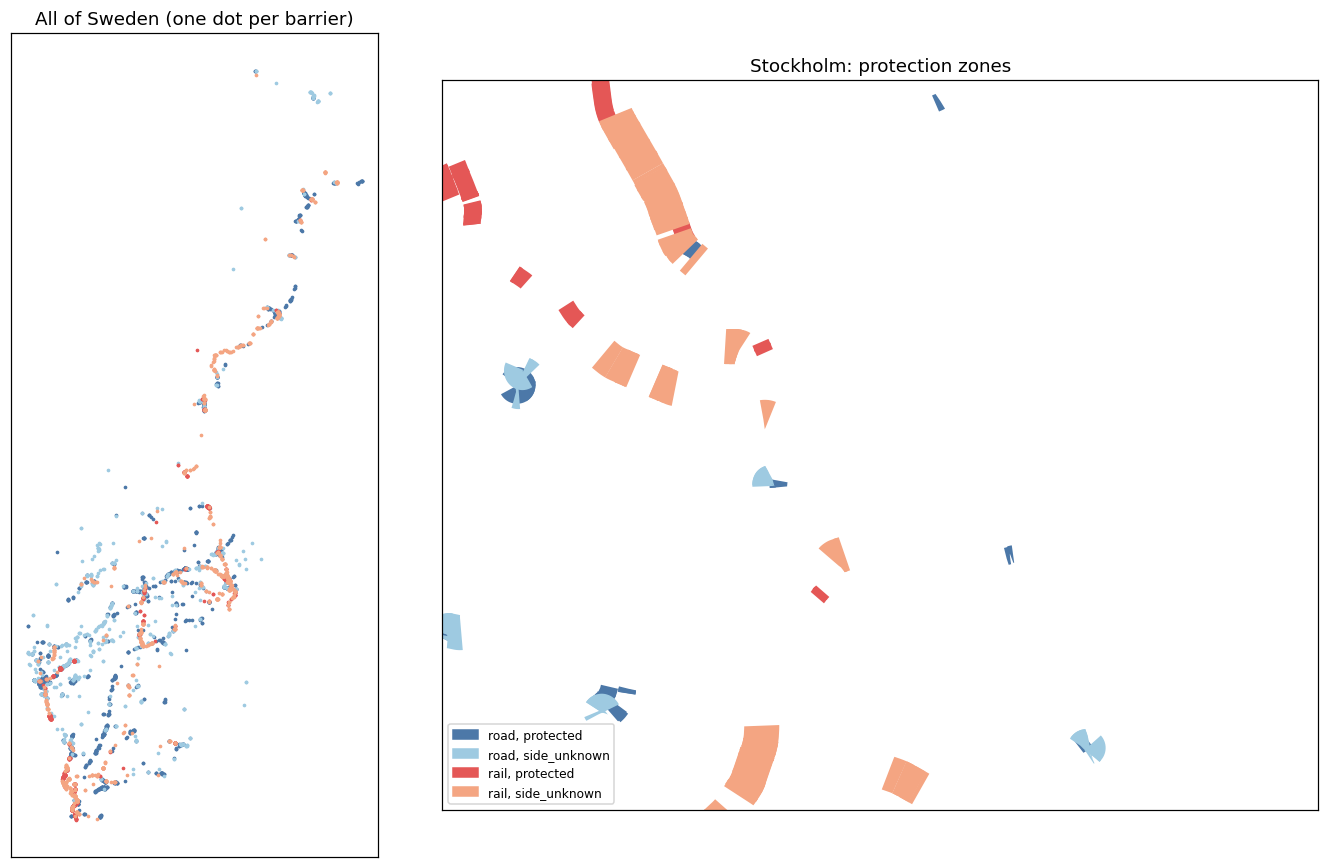

In [19]:
from src.regions.sweden.sources.barrier_protection.shared import load_protection_zones

from matplotlib.patches import Patch

zones_all = load_protection_zones()
# Dissolved first: zones of neighbouring barriers overlap.
area = (zones_all.dissolve(by=["kind", "zone_status"]).geometry.area / 1e6).round(1).unstack("zone_status")
display(area.rename_axis(columns="km², dissolved"))
display(zones_all.groupby(["kind", "side_method"]).size().unstack("kind").fillna(0).astype(int))

ZONE_COLORS = {
    ("road", "protected"): BLUE, ("road", "side_unknown"): "#9ECAE1",
    ("rail", "protected"): RED, ("rail", "side_unknown"): "#F4A582",
}
handles = [Patch(color=color, label=f"{kind}, {status}") for (kind, status), color in ZONE_COLORS.items()]
fig, axes = plt.subplots(1, 2, figsize=(13, 8), gridspec_kw={"width_ratios": [1, 1.6]})
# All of Sweden: one dot per barrier (the zones themselves are too small to see at this scale).
for (kind, status), color in ZONE_COLORS.items():
    sub = zones_all[(zones_all["kind"] == kind) & (zones_all["zone_status"] == status)]
    pts = sub.geometry.representative_point()
    axes[0].scatter(pts.x, pts.y, s=2, color=color)
axes[0].set_title("All of Sweden (one dot per barrier)")
bounds = (660_000, 6_570_000, 690_000, 6_595_000)
view = zones_all.cx[bounds[0]:bounds[2], bounds[1]:bounds[3]]
for (kind, status), color in ZONE_COLORS.items():
    sub = view[(view["kind"] == kind) & (view["zone_status"] == status)]
    if len(sub):
        sub.plot(ax=axes[1], color=color, linewidth=0)
axes[1].set_xlim(bounds[0], bounds[2]); axes[1].set_ylim(bounds[1], bounds[3])
axes[1].set_title("Stockholm: protection zones")
for ax in axes:
    ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
axes[1].legend(handles=handles, fontsize=8, loc="lower left")
plt.tight_layout()
plt.show()

## Notes & next steps

- **This is not SCB's real 100m grid.** It's a self-built tiling of the
  barrier corridor only, aligned to the same SW-corner-keyed convention so
  it would line up with the real MONA grid if that access is ever obtained.
- **The side is still unknown for many barriers** (§6-7), especially
  single-track rail and undivided roads. A **manual-audit app** is planned
  for the ones that decide a panel school's treatment
  (`barrier_matching.md` §7.4). It will feed in as the top-priority
  `side_method = "manual"`.
- **The `protected` margin (50m) is a choice.** `along_offset_m` and
  `lateral_m` are kept per cell so an analysis can vary it.
- **No panel/timing join yet.** This output stops at the static
  treated/untreated rollup; what the outcome is at 100m grain hasn't been
  decided.
- **`ASSUMED_BARRIER_REDUCTION_DB = 7.0`** (§5) is an assumption applied
  uniformly, not a measured per-barrier value.
- **No "proposed but not built" barriers:** Trafikverket's layer lists
  built assets only.